##Importación de Librerías y Carga de Datos

Para un pronóstico de series de tiempo clásico adaptado a Machine Learning, cruzaremos las ventas con la dimensión de tiempo para aprovechar variables como los feriados.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modelos de Regresión
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas de Evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Semilla de reproducibilidad
RANDOM_STATE = 42

# Carga de datos
ventas = pd.read_csv('../data/processed/fact_ventas.csv', sep=';')
tiempo = pd.read_csv('../data/processed/dim_tiempo.csv', sep=';')

# Aseguramos el tipo datetime
ventas['fecha'] = pd.to_datetime(ventas['fecha'])
tiempo['fecha'] = pd.to_datetime(tiempo['fecha'])

##Preparación de la Variable Objetivo (Ventas Diarias)

Vamos a agrupar todas las ventas a nivel diario. Si AndesMarket tuviera millones de registros, se podría hacer a nivel semanal, pero diario funciona muy bien para retail.

In [5]:
# Calculamos el importe real
ventas['importe'] = ventas['cantidad'] * ventas['precio_unitario_lista'] * (1 - ventas['descuento_pct'].fillna(0))

# Agrupamos las ventas totales por día
ventas_diarias = ventas.groupby('fecha')['importe'].sum().reset_index()
ventas_diarias.rename(columns={'importe': 'ventas_totales'}, inplace=True)

# Unimos con la dimensión tiempo para traer características temporales
df_regresion = ventas_diarias.merge(tiempo[['fecha', 'mes', 'dia_semana', 'es_feriado']], on='fecha', how='left')

# Verificamos que la serie esté ordenada cronológicamente (vital para series de tiempo)
df_regresion = df_regresion.sort_values('fecha').reset_index(drop=True)

##Feature Engineering (Variables Predictoras)

Para que los algoritmos de Machine Learning entiendan las secuencias, necesitamos crear variables temporales (estacionalidad) y, lo más importante, variables de rezago (lags).

In [6]:
# Variables estacionales: ya tenemos mes, dia_semana y es_feriado.
# Aseguramos que es_feriado sea numérica (0 o 1)
df_regresion['es_feriado'] = df_regresion['es_feriado'].astype(int)

# Variables de Rezago (Lags): ¿Cuánto se vendió ayer? ¿Cuánto se vendió el mismo día de la semana pasada?
df_regresion['ventas_ayer'] = df_regresion['ventas_totales'].shift(1)
df_regresion['ventas_semana_pasada'] = df_regresion['ventas_totales'].shift(7)

# Como al hacer shift() los primeros 7 días se quedan sin datos (NaN), los eliminamos
df_regresion = df_regresion.dropna().reset_index(drop=True)

# Definimos nuestras características (X) y el objetivo (y)
features = ['mes', 'dia_semana', 'es_feriado', 'ventas_ayer', 'ventas_semana_pasada']
X = df_regresion[features]
y = df_regresion['ventas_totales']

##División Respetando el Orden Temporal

Regla de oro: Jamás uses `train_test_split` aleatorio en series de tiempo porque mezclarías el futuro con el pasado. Debemos hacer un corte secuencial (ej. entrenar con el primer 80% del tiempo y validar con el 20% más reciente).

In [7]:
# Calculamos el índice de corte para el 80% de los datos
corte = int(len(df_regresion) * 0.8)

# Dividimos secuencialmente
X_train, X_test = X.iloc[:corte], X.iloc[corte:]
y_train, y_test = y.iloc[:corte], y.iloc[corte:]
fechas_test = df_regresion['fecha'].iloc[corte:]

print(f"Datos de entrenamiento: {len(X_train)} días")
print(f"Datos de prueba: {len(X_test)} días")

Datos de entrenamiento: 579 días
Datos de prueba: 145 días


Entrenamiento, Comparación y Evaluación de Modelos

Entrenaremos los tres modelos exigidos. Evaluaremos usando MAE (error promedio en dinero), RMSE (penaliza errores grandes), MAPE (porcentaje de error) y R².

In [8]:
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)
}

resultados = {}
predicciones_test = {}

for nombre, modelo in modelos.items():
    # Entrenamos
    modelo.fit(X_train, y_train)

    # Predecimos
    pred = modelo.predict(X_test)
    predicciones_test[nombre] = pred

    # Calculamos métricas
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
    r2 = r2_score(y_test, pred)

    print(f"--- {nombre} ---")
    print(f"MAE: S/ {mae:.2f}")
    print(f"RMSE: S/ {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²: {r2:.3f}\n")

--- Regresión Lineal ---
MAE: S/ 297.19
RMSE: S/ 373.02
MAPE: 15.86%
R²: 0.168

--- Random Forest ---
MAE: S/ 281.19
RMSE: S/ 354.96
MAPE: 14.45%
R²: 0.247

--- Gradient Boosting ---
MAE: S/ 261.19
RMSE: S/ 335.67
MAPE: 13.45%
R²: 0.327



##Visualización y Exportación a Power BI

Normalmente, el Gradient Boosting o el Random Forest dan el MAPE más bajo. Escogeremos el mejor modelo para exportar la comparativa entre la curva real y el pronóstico.

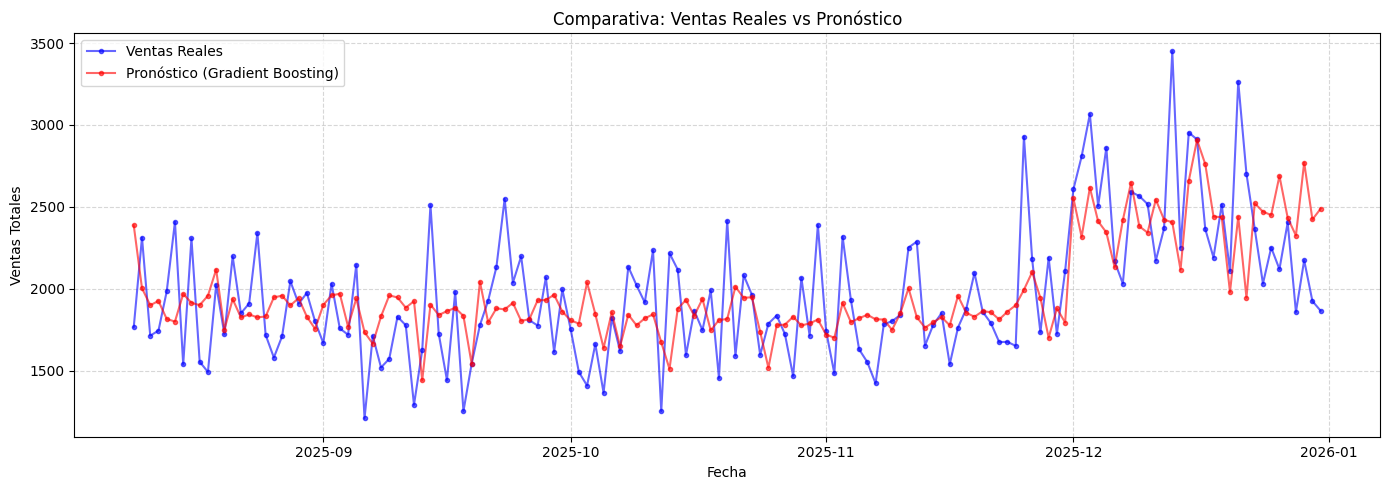

Pronóstico exportado exitosamente a pronostico_ventas.csv


In [9]:
# Supongamos que Gradient Boosting fue el mejor
mejor_modelo_nombre = "Gradient Boosting"
mejor_prediccion = predicciones_test[mejor_modelo_nombre]

# Gráfico para tu notebook y análisis visual
plt.figure(figsize=(14, 5))
plt.plot(fechas_test, y_test, label='Ventas Reales', marker='.', color='blue', alpha=0.6)
plt.plot(fechas_test, mejor_prediccion, label=f'Pronóstico ({mejor_modelo_nombre})', marker='.', color='red', alpha=0.6)
plt.title('Comparativa: Ventas Reales vs Pronóstico')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Armamos el DataFrame final para Power BI
export_pbi_regresion = pd.DataFrame({
    'fecha': fechas_test,
    'ventas_reales': y_test.values,
    'pronostico': mejor_prediccion,
    'error_absoluto': np.abs(y_test.values - mejor_prediccion)
})

# Exportamos a CSV
ruta_salida_regresion = '../data/processed/pronostico_ventas.csv'
export_pbi_regresion.to_csv(ruta_salida_regresion, sep=';', index=False)
print(f"Pronóstico exportado exitosamente a {ruta_salida_regresion}")